### punto 4

In [2]:
!pip install control

In [3]:
# Modelo del sistema y respuestas impulso/escalón
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from control.matlab import *   # funciones estilo MATLAB

In [4]:
# Parámetros del sistema
R = 0.5
Cs = 2
Cp = 0.2

# Funciones de transferencia
# X(s) = G1(s)F(s) - G2(s)Fo(s)

# G1(s) = (Cs*Cp*R*s + Cp) / ((R*Cs + R*Cp)*s + 1)
num_G1 = [Cs*Cp*R, Cp]
den_G1 = [R*Cs + R*Cp, 1]
G1 = ctrl.TransferFunction(num_G1, den_G1)

# G2(s) = (Cp*s) / ((R*Cs + R*Cp)*s + 1)
num_G2 = [Cp, 0]
den_G2 = [R*Cs + R*Cp, 1]
G2 = tf(num_G2, den_G2)

print("G1(s) =", G1)
print(" ")
print("G2(s) =", G2)

G1(s) = <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.2 s + 0.2
  -----------
   1.1 s + 1
 
G2(s) = <TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.2 s
  ---------
  1.1 s + 1


#### Respuesta al Impulso

c:\Users\USUARIO\anaconda3\Lib\site-packages\control\timeresp.py:2015: UserWarning: System has direct feedthrough: `D != 0`. The infinite impulse at `t=0` does not appear in the output.
Results may be meaningless!
  warnings.warn("System has direct feedthrough: `D != 0`. The "


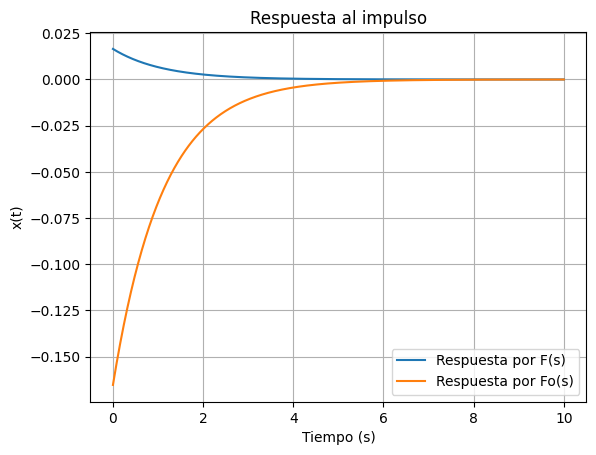

In [5]:
t = np.linspace(0, 10, 1000)

# --- Escalón ---
y1, t1 = impulse(G1, T=t)
y2, t2 = impulse(G2, T=t)
plt.figure(1)
plt.plot(t1, y1, label="Respuesta por F(s)")
plt.plot(t2, y2, label="Respuesta por Fo(s)")

plt.title("Respuesta al impulso")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

#### Respuesta al Escalon

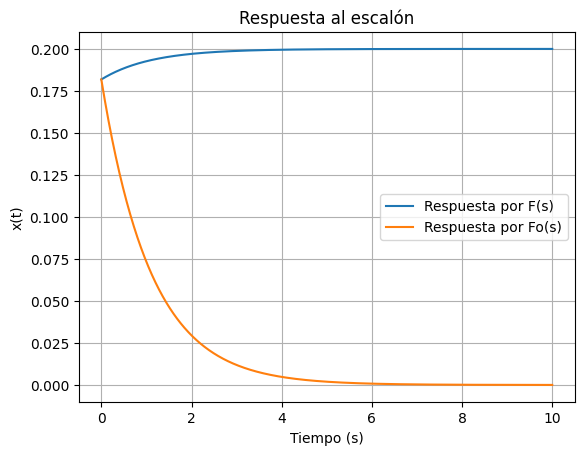

In [6]:
# Respuesta al escalón

# --- Escalón ---
y1, t1 = step(G1, T=t)
y2, t2 = step(G2, T=t)
plt.figure(1)
plt.plot(t1, y1, label="Respuesta por F(s)")
plt.plot(t2, y2, label="Respuesta por Fo(s)")

plt.title("Respuesta al escalón")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

plt.show()

In [7]:
# Tiempo de muestreo
Ts = 0.1

# Transformada Z (discretización)
G1z = ctrl.c2d(G1, Ts, method='zoh')
G2z = ctrl.c2d(G2, Ts, method='zoh')

print("\nG1(z) =")
print(G1z)

print("\nG2(z) =")
print(G2z)



G1(z) =
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.1818 z - 0.1644
  -----------------
     z - 0.9131

G2(z) =
<TransferFunction>: sys[1]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.1818 z - 0.1818
  -----------------
     z - 0.9131


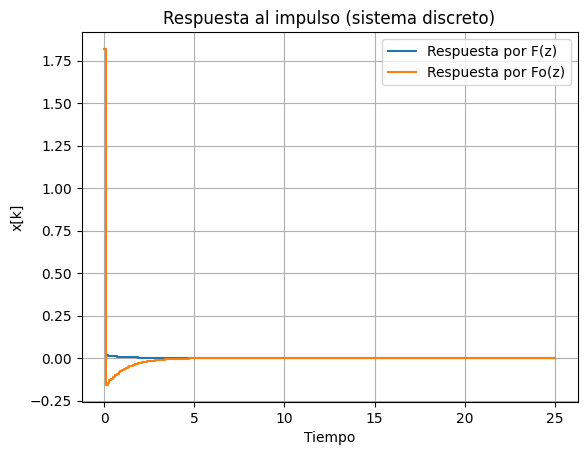

In [8]:
# Respuesta impulso (sistema discreto)

t_imp, y_imp = ctrl.impulse_response(G1z)

plt.figure(3)
plt.step(t_imp, y_imp, where="post", label="Respuesta por F(z)")

t2_imp, y2_imp = ctrl.impulse_response(G2z)
plt.step(t2_imp, y2_imp, where="post", label="Respuesta por Fo(z)")

plt.title("Respuesta al impulso (sistema discreto)")
plt.xlabel("Tiempo")
plt.ylabel("x[k]")
plt.legend()
plt.grid()

plt.show()

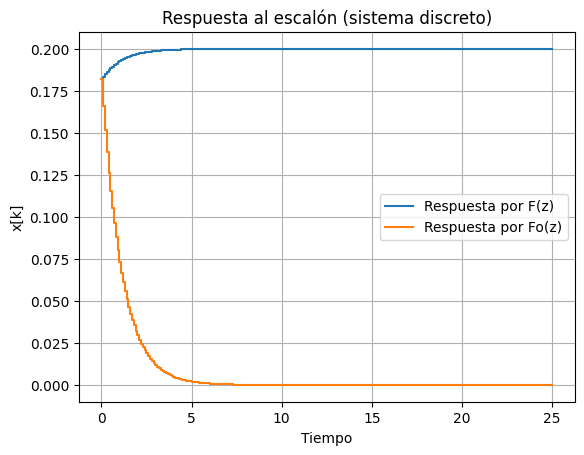

In [9]:
# Respuesta escalón (sistema discreto)

t_step, y_step = ctrl.step_response(G1z)

plt.figure(4)
plt.step(t_step, y_step, where="post", label="Respuesta por F(z)")

t2_step, y2_step = ctrl.step_response(G2z)
plt.step(t2_step, y2_step, where="post", label="Respuesta por Fo(z)")

plt.title("Respuesta al escalón (sistema discreto)")
plt.xlabel("Tiempo")
plt.ylabel("x[k]")
plt.legend()
plt.grid()

plt.show()

## Patologias Musculares

#### Miastenia Gravis

In [23]:
# Nuevos parametros del sistema
R = 0.5
Cs = 2
Cp = 0.15 # Que es 25% menor que el valor normal

num_G1_m = [Cs*Cp*R, Cp]
den_G1_m = [R*Cs + R*Cp, 1]

# G2(s) = (Cp*s) / ((R*Cs + R*Cp)*s + 1)
num_G2_m = [Cp, 0]
den_G2_m = [R*Cs + R*Cp, 1]

G1_m = tf(num_G1_m, den_G1_m)
G2_m = tf(num_G2_m, den_G2_m)

print("G1(s) =", G1_m)
print(" ")
print("G2(s) =", G2_m)

G1(s) = <TransferFunction>: sys[56]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.15 s + 0.15
  -------------
   1.075 s + 1
 
G2(s) = <TransferFunction>: sys[57]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.15 s
  -----------
  1.075 s + 1


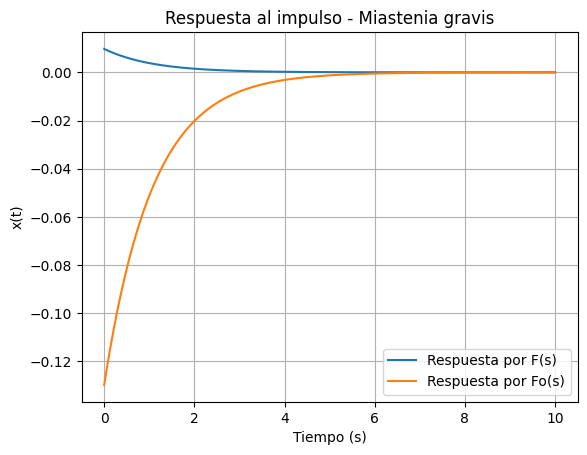

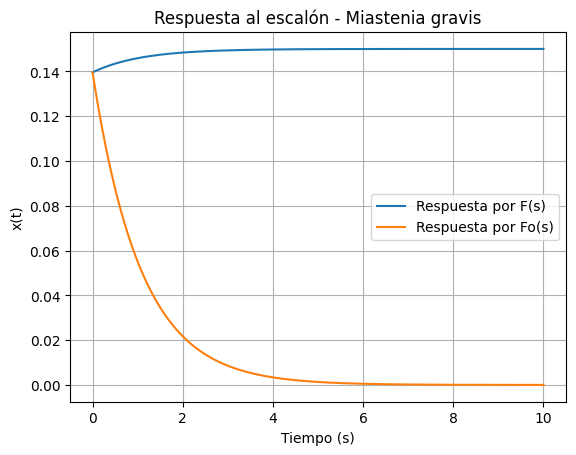

In [24]:
#### Respuesta al Impulso
t = np.linspace(0, 10, 1000)

# --- Impulso ---
y1_m, t1_m = impulse(G1_m, T=t)
y2_m, t2_m = impulse(G2_m, T=t)

plt.figure()
plt.plot(t1_m, y1_m, label="Respuesta por F(s)")
plt.plot(t2_m, y2_m, label="Respuesta por Fo(s)")

plt.title("Respuesta al impulso - Miastenia gravis")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()


#### Respuesta al Escalón

# --- Escalón ---
y1s_m, t1s_m = step(G1_m, T=t)
y2s_m, t2s_m = step(G2_m, T=t)

plt.figure()
plt.plot(t1s_m, y1s_m, label="Respuesta por F(s)")
plt.plot(t2s_m, y2s_m, label="Respuesta por Fo(s)")

plt.title("Respuesta al escalón - Miastenia gravis")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

### Distrofia Muscular 

In [17]:
# Parámetros del sistema para simulación de Distrofia Muscular

R_dm = 1.0        # aumento de viscosidad (≈100% mayor que el valor normal 0.5)
Cs_dm = 1.0       # reducción de elasticidad estructural (≈50% menor que 2)
Cp_dm = 0.10      # reducción de capacidad contráctil (≈50% menor que 0.2)

num_G1_dm = [Cs_dm * Cp_dm * R_dm, Cp_dm]
den_G1_dm = [R_dm * Cs_dm + R_dm * Cp_dm, 1]

# G2(s) = (Cp*s) / ((R*Cs + R*Cp)*s + 1)
num_G2_dm = [Cp_dm, 0]
den_G2_dm = [R_dm * Cs_dm + R_dm * Cp_dm, 1]

G1_dm = tf(num_G1_dm, den_G1_dm)
G2_dm = tf(num_G2_dm, den_G2_dm)

print("G1_distrofia(s) =", G1_dm)
print(" ")
print("G2_distrofia(s) =", G2_dm)

G1_distrofia(s) = <TransferFunction>: sys[36]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.1 s + 0.1
  -----------
   1.1 s + 1
 
G2_distrofia(s) = <TransferFunction>: sys[37]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.1 s
  ---------
  1.1 s + 1


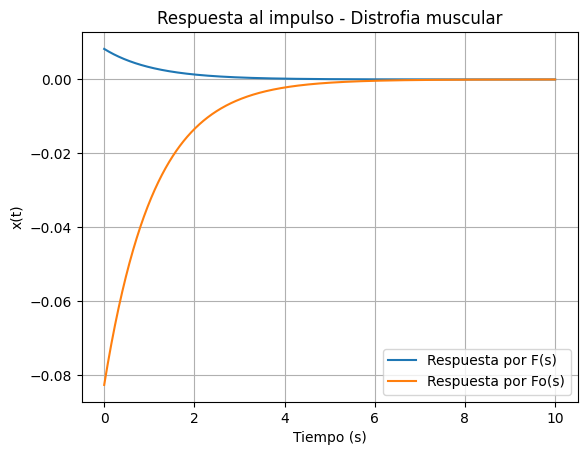

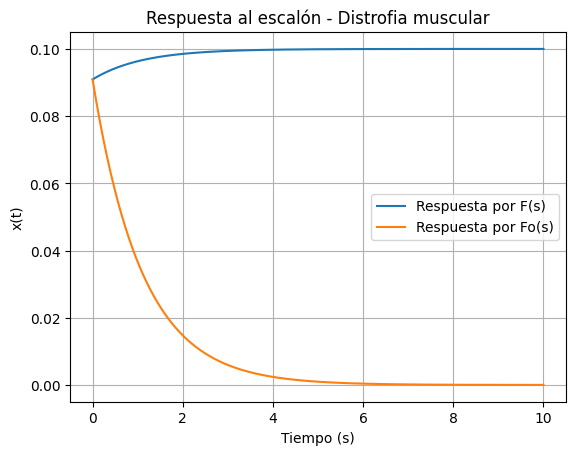

In [18]:
#### Tiempo de simulación
t_dm = np.linspace(0, 10, 1000)

#### Respuesta al Impulso - Distrofia Muscular

y1_dm, t1_dm = impulse(G1_dm, T=t_dm)
y2_dm, t2_dm = impulse(G2_dm, T=t_dm)

plt.figure()
plt.plot(t1_dm, y1_dm, label="Respuesta por F(s)")
plt.plot(t2_dm, y2_dm, label="Respuesta por Fo(s)")

plt.title("Respuesta al impulso - Distrofia muscular")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()


#### Respuesta al Escalón - Distrofia Muscular

y1s_dm, t1s_dm = step(G1_dm, T=t_dm)
y2s_dm, t2s_dm = step(G2_dm, T=t_dm)

plt.figure()
plt.plot(t1s_dm, y1s_dm, label="Respuesta por F(s)")
plt.plot(t2s_dm, y2s_dm, label="Respuesta por Fo(s)")

plt.title("Respuesta al escalón - Distrofia muscular")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()